# Tier-2 architecture ablation 2 — positional embedding off vs on

The Conformer paper reports that the hybrid does **not** need explicit positional embeddings — the conv branch and FCU coupling already inject spatial structure. The stock backbone in your repo confirms this: it has a `cls_token` but **no `pos_embed`**. This notebook tests that choice on your data by adding an optional learnable positional embedding to the transformer tokens of the **dual** model (your actual model) and comparing **off vs on** under the same 5-fold CV and the same whole-image pipeline as `hto_correction_angles.ipynb`.

- **pos_embed_off** — stock dual model (no positional embedding).
- **pos_embed_on** — identical, plus a learnable `pos_embed` of shape `(1, num_patches+1, embed_dim)` added to the tokens before the first transformer block.

Everything else (data, folds, schedule, training loop, evaluation) is identical, so any difference is attributable to the positional embedding alone.

> *Not executed here (no GPU / data / `CKD`). Syntax- and `nbformat`-validated only. Heavy: 2 arms × 5 folds × `ARCH_EPOCHS`. Read per-fold MAE (printed) with a paired test plus the mean ± std.*


## 1 · Setup & configuration

The one-stage notebook's setup (imports, paths, seed, `device`) plus a small Tier-2 config (`N_SPLITS`, `ARCH_EPOCHS`). `ARCH_EPOCHS` defaults to the one-stage budget for a fair comparison; lower it for a quick pass.


In [1]:
import os
import json
import random
import math
import sys
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn

sys.path.append(os.path.abspath("CKD"))
from models import (
    Conformer_tiny_patch16_keypoint_half_heatmap,
    Conformer_small_patch16_keypoint_half_heatmap,
    Conformer_small_patch32_keypoint_half_heatmap,
    Conformer_base_patch16_keypoint_half_heatmap,
)
from utils import extract_coordinates

DATA_DIR       = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "hto_annotations.json")
if not os.path.exists(COCO_JSON_PATH):
    COCO_JSON_PATH = "hto_annotations.json"

SEED           = 42
TARGET_SIZE    = 768
HEATMAP_SCALE  = 0.5
SIGMA          = 6.0
KP_EPOCHS      = 2_000
BATCH_SIZE     = 4
LEARNING_RATE  = 1e-4 * (HEATMAP_SCALE / 0.25)

MODEL_VARIANT   = "small_p16"
CHECKPOINT_PATH = "kfolds_models/best_model_global.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware device registered: {device}")

GLOBAL_KEYPOINT_NAMES = [
    "femur_head_lh", "knee_inner_lh", "ost_point_lh",
    "knee_outer_lh", "ankle_inner_lh", "ankle_outer_lh",
    "femur_head_rh", "knee_inner_rh", "ost_point_rh",
    "knee_outer_rh", "ankle_inner_rh", "ankle_outer_rh",
]

LANDMARK_COLORS = {
    "femur_head_lh":      "darkgreen",  "knee_inner_lh":    "darkblue",
    "ost_point_lh":       "darkred",    "knee_outer_lh":    "darkviolet",
    "ankle_inner_lh":     "darkorange", "ankle_outer_lh":   "teal",
    "fujisawa_lh":        "gold",       "ankle_c_lh":       "navy",
    "target_at_ankle_lh": "magenta",
    "femur_head_rh":      "lightgreen", "knee_inner_rh":    "lightblue",
    "ost_point_rh":       "lightcoral", "knee_outer_rh":    "plum",
    "ankle_inner_rh":     "sandybrown", "ankle_outer_rh":   "paleturquoise",
    "fujisawa_rh":        "khaki",      "ankle_c_rh":       "slategray",
    "target_at_ankle_rh": "violet",
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)


# ── Tier-2 architecture-ablation config ─────────────────────────────────────
# Reuses the one-stage whole-image pipeline (768 px, 12 keypoints, heatmap loss,
# Miniaci geometry, agreement battery). Only the BACKBONE changes between arms.
N_SPLITS    = 5
ARCH_EPOCHS = KP_EPOCHS     # same budget as the one-stage run for a fair comparison;
                            #   lower (e.g. 300-600) for a quick pass, raise for finals.
print(f"Architecture-ablation config | variant={MODEL_VARIANT} | folds={N_SPLITS} | epochs={ARCH_EPOCHS}")


Hardware device registered: cuda
Architecture-ablation config | variant=small_p16 | folds=5 | epochs=2000


/usr/local/lib/python3.11/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/tf/notebooks/CKD/vision_transformer.py:370: UserWarning: Overwriting vit_small_patch16_224 in registry with vision_transformer.vit_small_patch16_224. This is because the name being registe

In [2]:
print(f"PyTorch version: {torch.__version__}")
gpu_available = torch.cuda.is_available()
print(f"GPU available: {gpu_available}")
if gpu_available:
    print(f"GPU device name: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.5.1+cu121
GPU available: True
GPU device name: NVIDIA H100 80GB HBM3


## 2 · Reused one-stage machinery (verbatim)

Image preprocessing/augmentation, the COCO keypoint dataset, the masked-heatmap loss and metrics, the Miniaci geometry with `evaluate_fold_angles`, the agreement battery, the differentiable angle layer, and `train_global_routine` — copied unchanged from `hto_correction_angles.ipynb`. The harness forces heatmap-only training (`ANGLE_LOSS_WEIGHT = 0`) so the comparison isolates the backbone.


In [3]:
def preprocess_global_image(img, target_size=512):
    """Letterbox-resize *img* to a square canvas of *target_size* pixels."""
    orig_w, orig_h = img.size
    scale   = min(target_size / orig_w, target_size / orig_h)
    new_w   = int(orig_w * scale)
    new_h   = int(orig_h * scale)
    resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    pad_left = (target_size - new_w) // 2
    pad_top  = (target_size - new_h) // 2
    final_img = Image.new("RGB", (target_size, target_size), (0, 0, 0))
    final_img.paste(resized, (pad_left, pad_top))
    return final_img, scale, (pad_left, pad_top)


def apply_augmentation(pil_img, final_kps):
    """Stochastic photometric and geometric augmentations.
    Returns (augmented_img, updated_kps)."""
    import torchvision.transforms.functional as TF
    import cv2

    img = pil_img
    kps = [list(kp) for kp in final_kps]
    W, H = img.size

    if random.random() < 0.6:
        img = TF.adjust_brightness(img, 1.0 + random.uniform(-0.25, 0.25))
    if random.random() < 0.6:
        img = TF.adjust_contrast(img, 1.0 + random.uniform(-0.25, 0.25))

    if random.random() < 0.4:
        arr   = np.array(img, dtype=np.float32)
        noise = np.random.normal(0, random.uniform(3, 12), arr.shape)
        arr   = np.clip(arr + noise, 0, 255).astype(np.uint8)
        img   = Image.fromarray(arr)

    if random.random() < 0.5:
        gamma = random.uniform(0.7, 1.4)
        arr   = np.array(img, dtype=np.float32) / 255.0
        img   = Image.fromarray((np.power(arr, gamma) * 255).astype(np.uint8))

    if random.random() < 0.4:
        arr       = np.array(img)
        clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        processed = clahe.apply(arr[:, :, 0])
        img       = Image.fromarray(np.stack([processed] * 3, axis=2))

    if random.random() < 0.3:
        img = TF.adjust_sharpness(img, random.uniform(0.5, 2.0))

    if random.random() < 0.5:
        angle    = random.uniform(-10, 10)
        img      = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)
        cx, cy   = W / 2.0, H / 2.0
        rad      = math.radians(-angle)
        cos_a, sin_a = math.cos(rad), math.sin(rad)
        for kp in kps:
            if kp[0] < 0: continue
            dx, dy = kp[0] - cx, kp[1] - cy
            kp[0]  = cos_a * dx - sin_a * dy + cx
            kp[1]  = sin_a * dx + cos_a * dy + cy
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    if random.random() < 0.3:
        shift_y = random.randint(-15, 15)
        img = TF.affine(img, angle=0, translate=(0, shift_y), scale=1.0, shear=0)
        for kp in kps:
            if kp[0] < 0: continue
            kp[1] += shift_y
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    if random.random() < 0.3:
        sf    = random.uniform(0.90, 1.10)
        new_w = int(W * sf); new_h = int(H * sf)
        img   = TF.resize(img, [new_h, new_w])
        if sf < 1.0:
            pl, pt = (W - new_w) // 2, (H - new_h) // 2
            padded = Image.new("RGB", (W, H), (0, 0, 0))
            padded.paste(img, (pl, pt))
            img = padded; ox, oy = pl, pt
        else:
            cl, ct = (new_w - W) // 2, (new_h - H) // 2
            img = TF.crop(img, ct, cl, H, W); ox, oy = -cl, -ct
        for kp in kps:
            if kp[0] < 0: continue
            kp[0] = kp[0] * sf + ox; kp[1] = kp[1] * sf + oy
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    return img, kps


In [4]:
def _rep_x(ann):
    """Representative x-coordinate for hemisphere assignment.
 
    Uses the mean of all visible keypoint x-values so that the decision is
    driven by where the actual anatomy sits, not by where the annotator drew
    the bounding box.  Falls back to the bbox centre only when every keypoint
    is (0, 0, 0) (i.e. the annotation box exists but contains no points yet).
    """
    kps = ann.get("keypoints", [])
    xs  = [kps[i] for i in range(0, len(kps), 3) if kps[i] > 0]
    if xs:
        return sum(xs) / len(xs)
    bbox = ann.get("bbox", [0, 0, 0, 0])
    return bbox[0] + bbox[2] / 2
 
 
# ── dataset ───────────────────────────────────────────────────────────────────
 
class GlobalRadiographKeypointDataset(Dataset):
    """COCO-style dataset for global 12-keypoint detection on long-leg radiographs.
 
    Hemisphere assignment
    ---------------------
    Annotations are grouped by category.  For each category, the annotation
    with the *smaller* representative x goes to the left hemisphere (base=0,
    slots 0-5) and the one with the *larger* representative x goes to the
    right hemisphere (base=6, slots 11).  This is a purely relative decision
    — no fixed image-midpoint threshold is involved — so it is robust to
    bounding boxes that straddle the image centre-line (the root cause of the
    misassignment in 23_0.png / 20_0.png with the old loader).
 
    The fallback to the image midpoint is kept only for categories that have
    exactly one annotation, where relative ordering is impossible.
 
    Parameters
    ----------
    indices : list[int] or None
        Explicit sample positions into the shuffled pool.  When given,
        split_ratios are ignored — used by the k-fold cross-validation loop.
    """
 
    def __init__(
        self,
        coco_json_path,
        split="train",
        split_ratios=(0.8, 0.1, 0.1),
        target_size=512,
        heatmap_scale=0.25,
        sigma=2.0,
        seed=42,
        indices=None,
    ):
        super().__init__()
        self.target_size   = target_size
        self.heatmap_scale = heatmap_scale
        self.sigma         = sigma
        self.num_keypoints = 12
        self.split         = split
 
        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
 
        images_info = {img["id"]: img for img in coco_data.get("images", [])}
 
        # ── group annotations by image ────────────────────────────────────
        anns_by_img = {}
        for ann in coco_data.get("annotations", []):
            anns_by_img.setdefault(ann.get("image_id"), []).append(ann)
 
        # ── build valid samples ───────────────────────────────────────────
        valid_samples = []
 
        for img_id, anns in anns_by_img.items():
            if img_id not in images_info:
                continue
 
            img_info = images_info[img_id]
            img_w    = img_info.get("width", 2860)
 
            # ── hemisphere assignment: relative, not midpoint-based ───────
            # Group annotations for this image by category, then assign
            # left / right by sorting on representative x.
            by_cat = {}
            for ann in anns:
                by_cat.setdefault(ann.get("category_id"), []).append(ann)
 
            kps_flat = [-1.0, -1.0, 0] * 12
            has_kp   = False
 
            for cat_id, cat_anns in by_cat.items():
                sorted_anns = sorted(cat_anns, key=_rep_x)
 
                if len(sorted_anns) == 2:
                    # Common case: one annotation per leg.
                    # Smaller x → left hemisphere, larger x → right hemisphere.
                    assignments = [(sorted_anns[0], 0), (sorted_anns[1], 6)]
 
                elif len(sorted_anns) == 1:
                    # Only one leg annotated for this category.
                    # Fall back to absolute image midpoint.
                    x    = _rep_x(sorted_anns[0])
                    base = 0 if x < img_w / 2.0 else 6
                    assignments = [(sorted_anns[0], base)]
 
                else:
                    # More than two annotations: take the leftmost and
                    # rightmost and discard the rest.
                    assignments = [(sorted_anns[0], 0), (sorted_anns[-1], 6)]
 
                for ann, base in assignments:
                    kps = ann.get("keypoints", [])
                    if cat_id == 1 and len(kps) >= 3:
                        kps_flat[base * 3:(base + 1) * 3] = [
                            kps[0], kps[1], 2 if kps[0] > 0 else 0
                        ]
                        if kps[0] > 0:
                            has_kp = True
 
                    elif cat_id == 2 and len(kps) >= 9:
                        for k in range(3):
                            s = base + 1 + k
                            kps_flat[s * 3:(s + 1) * 3] = [
                                kps[k * 3], kps[k * 3 + 1], kps[k * 3 + 2]
                            ]
                            if kps[k * 3 + 2] > 0:
                                has_kp = True
 
                    elif cat_id == 3 and len(kps) >= 6:
                        for k in range(2):
                            s = base + 4 + k
                            kps_flat[s * 3:(s + 1) * 3] = [
                                kps[k * 3], kps[k * 3 + 1], kps[k * 3 + 2]
                            ]
                            if kps[k * 3 + 2] > 0:
                                has_kp = True
 
            if has_kp:
                filename = img_info.get("file_name")
                img_dir  = os.path.dirname(coco_json_path) or "."
                if not os.path.exists(os.path.join(img_dir, filename)):
                    alt = os.path.join("/tf/data/hto/xrays", os.path.basename(filename))
                    if os.path.exists(alt):
                        img_dir = "/tf/data/hto/xrays"
                valid_samples.append({
                    "img_path":  os.path.join(img_dir, filename),
                    "orig_size": (img_w, img_info.get("height", 8000)),
                    "keypoints": kps_flat,
                })
 
        # ── deterministic shuffle, then split ─────────────────────────────
        valid_samples.sort(key=lambda x: x["img_path"])
        random.seed(seed)
        random.shuffle(valid_samples)
 
        if indices is not None:
            self.samples = [valid_samples[i] for i in indices]
        else:
            n         = len(valid_samples)
            train_end = int(n * split_ratios[0])
            val_end   = train_end + int(n * split_ratios[1])
            self.samples = {
                "train": valid_samples[:train_end],
                "val":   valid_samples[train_end:val_end],
                "test":  valid_samples[val_end:],
            }.get(split, valid_samples)   # "all" (or any unknown key) → full list
 
    # ── protocol ──────────────────────────────────────────────────────────────
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        sample = self.samples[idx]
 
        try:
            img = Image.open(sample["img_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", sample["orig_size"], color=(128, 128, 128))
 
        processed_img, scale, padding = preprocess_global_image(img, self.target_size)
 
        # ── map keypoints into the padded canvas ──────────────────────────
        final_kps, kp_visibility = [], []
        for i in range(self.num_keypoints):
            kp_x = sample["keypoints"][i * 3]
            kp_y = sample["keypoints"][i * 3 + 1]
            kp_v = sample["keypoints"][i * 3 + 2]
            if kp_v > 0 and kp_x >= 0 and kp_y >= 0:
                final_kps.append([kp_x * scale + padding[0],
                                   kp_y * scale + padding[1]])
                kp_visibility.append(1.0)
            else:
                final_kps.append([-1.0, -1.0])
                kp_visibility.append(0.0)
 
        # ── augmentation (training only) ──────────────────────────────────
        if self.split == "train":
            processed_img, final_kps = apply_augmentation(processed_img, final_kps)
            kp_visibility = [
                1.0 if final_kps[i][0] >= 0 else 0.0
                for i in range(self.num_keypoints)
            ]
 
        # ── normalise image ───────────────────────────────────────────────
        img_tensor = (
            torch.from_numpy(np.array(processed_img))
            .permute(2, 0, 1)
            .float()
            / 255.0
        )
        img_tensor = (
            img_tensor - torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        ) / torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
 
        # ── build Gaussian heatmap targets ────────────────────────────────
        hm_size = int(self.target_size * self.heatmap_scale)
        heatmap = np.zeros((self.num_keypoints, hm_size, hm_size), dtype=np.float32)
        x_grid  = np.arange(0, hm_size, 1, np.float32)
        y_grid  = np.arange(0, hm_size, 1, np.float32)[:, np.newaxis]
 
        for i in range(self.num_keypoints):
            if sample["keypoints"][i * 3 + 2] > 0 and final_kps[i][0] >= 0:
                hx = final_kps[i][0] * self.heatmap_scale
                hy = final_kps[i][1] * self.heatmap_scale
                heatmap[i] = np.exp(
                    -((x_grid - hx) ** 2 + (y_grid - hy) ** 2)
                    / (2 * self.sigma ** 2)
                )
 
        return {
            "image":    img_tensor,
            "heatmap":  torch.from_numpy(heatmap),
            "keypoint": torch.tensor(final_kps, dtype=torch.float32),
            "visibility": torch.tensor(kp_visibility, dtype=torch.float32),
            "img_path": sample["img_path"],
            "orig_size": torch.tensor(sample["orig_size"]),
        }


In [5]:
def masked_heatmap_loss(pred_hms, target_hms, visibility):
    """Per-channel MSE loss masked to visible keypoints."""
    mask        = visibility.unsqueeze(-1).unsqueeze(-1)
    masked_diff = (pred_hms - target_hms) ** 2 * mask
    H, W        = pred_hms.shape[-2], pred_hms.shape[-1]
    return masked_diff.sum() / (mask.sum().clamp(min=1) * H * W)


def calculate_mse(preds, gts):
    """Mean Squared Error (px\u00b2) over all valid keypoints."""
    valid_mask = gts[..., 0] >= 0
    if not torch.any(valid_mask): return 0.0
    return torch.mean(torch.sum((preds - gts) ** 2, dim=-1)[valid_mask]).item()


def calculate_pck(preds, gts, threshold=0.05, normalize_by=512):
    """Percentage of Correct Keypoints at *threshold* \u00d7 *normalize_by* px."""
    valid_mask = gts[..., 0] >= 0
    if not torch.any(valid_mask): return 0.0
    correct = torch.norm(preds - gts, dim=-1) < (threshold * normalize_by)
    return torch.mean(correct[valid_mask].float()).item()


PCK_THRESHOLDS = [0.005, 0.01, 0.02, 0.05]


In [6]:
def map_global_to_orig(kp_final, orig_size, target_size=512):
    """Invert the letterbox transform back to original image coordinates."""
    orig_w, orig_h = orig_size
    scale    = min(target_size / orig_w, target_size / orig_h)
    pad_left = (target_size - int(orig_w * scale)) // 2
    pad_top  = (target_size - int(orig_h * scale)) // 2
    return np.array([(kp_final[0] - pad_left) / scale,
                     (kp_final[1] - pad_top)  / scale])


def calculate_intersection(p1, p2, target_y):
    """X-coordinate where line (p1 → p2) crosses y = *target_y*."""
    if p2[0] == p1[0]: return p1[0]
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    if m == 0:
        return p1[0] if abs(target_y - p1[1]) < 1e-9 else float("nan")
    return (target_y - p1[1]) / m + p1[0]


def evaluate_side_geometry(points):
    """Compute the Miniaci correction angle Alpha for one leg hemisphere.

    Parameters
    ----------
    points : dict with keys femur_head, knee_inner, ost_point,
             knee_outer, ankle_inner, ankle_outer (2-element arrays)

    Returns
    -------
    alpha, fujisawa, ankle_c, target_at_ankle
    """
    ankle_c  = (points["ankle_inner"] + points["ankle_outer"]) / 2.0
    fujisawa = points["knee_inner"] + 0.625 * (points["knee_outer"] - points["knee_inner"])

    tx              = calculate_intersection(points["femur_head"], fujisawa, ankle_c[1])
    target_at_ankle = np.array([tx, ankle_c[1]])

    v_orig   = ankle_c         - points["ost_point"]
    v_target = target_at_ankle - points["ost_point"]
    raw      = abs(math.atan2(v_orig[1], v_orig[0]) - math.atan2(v_target[1], v_target[0]))
    alpha    = min(raw, 2 * math.pi - raw) * 180.0 / math.pi
    return alpha, fujisawa, ankle_c, target_at_ankle


_SIDE_KEYS = ["femur_head", "knee_inner", "ost_point",
              "knee_outer", "ankle_inner", "ankle_outer"]


def evaluate_fold_angles(model, v_loader, dev):
    """Run inference on *v_loader* and return a dict of correction-angle
    error statistics across all valid hemisphere cases:

        mae  – mean absolute error (degrees)
        std  – standard deviation of absolute errors (degrees)
        max  – maximum absolute error (degrees)
        n    – number of valid hemisphere cases evaluated

    Returns None if no valid hemisphere pairs are found.
    """
    model.eval()
    abs_errors = []
    gt_list, pred_list = [], []

    with torch.no_grad():
        for batch in v_loader:
            imgs         = batch["image"].to(dev)
            pred_hms     = torch.sigmoid(model(imgs))
            coords_batch = extract_coordinates(
                pred_hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE
            ).numpy()
            gts_batch  = batch["keypoint"].numpy()
            orig_sizes = batch["orig_size"].numpy()

            for b in range(len(imgs)):
                orig_shape = orig_sizes[b]
                pred_c     = coords_batch[b]
                gt_c       = gts_batch[b]

                for base in [0, 6]:   # left hemisphere, right hemisphere
                    pts_gt, pts_pred = {}, {}
                    for k_off, name in enumerate(_SIDE_KEYS):
                        slot = base + k_off
                        if gt_c[slot][0] >= 0:
                            pts_gt[name]   = map_global_to_orig(gt_c[slot],   orig_shape, TARGET_SIZE)
                            pts_pred[name] = map_global_to_orig(pred_c[slot], orig_shape, TARGET_SIZE)

                    if (all(k in pts_gt   for k in _SIDE_KEYS) and
                            all(k in pts_pred for k in _SIDE_KEYS)):
                        gt_alpha,   *_ = evaluate_side_geometry(pts_gt)
                        pred_alpha, *_ = evaluate_side_geometry(pts_pred)
                        abs_errors.append(abs(pred_alpha - gt_alpha))
                        gt_list.append(float(gt_alpha)); pred_list.append(float(pred_alpha))

    if not abs_errors:
        return None
    arr = np.array(abs_errors)
    return {"mae": float(arr.mean()),
            "std": float(arr.std()),
            "max": float(arr.max()),
            "n":   len(arr),
            "gt":  gt_list,
            "pred": pred_list}


In [7]:
# ============================================================================
# Correction-angle agreement statistics  (ports compute_stats.py into the
# notebook so the standalone scripts are no longer needed). CPU-only.
#
# Given paired arrays of ground-truth and predicted correction angles (one
# value per limb hemisphere), angle_agreement_report() prints and returns the
# full battery: mean / median / std / min / max absolute error, RMSE, % within
# the clinical tolerance, ICC(2,1) with 95% CI, Pearson r, and Bland-Altman
# bias + 95% limits of agreement.
# ============================================================================
import pandas as pd

CLINICAL_TOLERANCE_DEG = 1.63          # Jiang et al. correction-angle tolerance


def icc21_manual(ratings):
    """ICC(2,1): two-way random, absolute agreement, single measurement.
    ratings: array (n_targets, k_raters). Point estimate (Shrout & Fleiss 1979)."""
    ratings = np.asarray(ratings, dtype=float)
    n, k = ratings.shape
    grand     = ratings.mean()
    row_means = ratings.mean(axis=1, keepdims=True)
    col_means = ratings.mean(axis=0, keepdims=True)
    ss_total = ((ratings - grand) ** 2).sum()
    ss_row   = k * ((row_means - grand) ** 2).sum()
    ss_col   = n * ((col_means - grand) ** 2).sum()
    ss_err   = ss_total - ss_row - ss_col
    ms_row = ss_row / (n - 1)
    ms_col = ss_col / (k - 1)
    ms_err = ss_err / ((n - 1) * (k - 1))
    denom = ms_row + (k - 1) * ms_err + (k / n) * (ms_col - ms_err)
    return float((ms_row - ms_err) / denom)


def compute_icc(gt, pred):
    """(icc, ci_low, ci_high, method). pingouin gives the exact 95% CI if
    installed; otherwise a manual ICC(2,1) point estimate (no CI). The two
    'raters' are the mean-observer GT and the automatic method."""
    gt   = np.asarray(gt, dtype=float)
    pred = np.asarray(pred, dtype=float)
    n = len(gt)
    try:
        import pingouin as pg
        long = pd.DataFrame({
            "target": list(range(n)) * 2,
            "rater":  ["mean_observer"] * n + ["auto"] * n,
            "angle":  np.concatenate([gt, pred]),
        })
        res = pg.intraclass_corr(data=long, targets="target", raters="rater", ratings="angle")
        row = res.loc[res["Type"].isin(["ICC2", "ICC(A,1)"])].iloc[0]
        ci_col = "CI95%" if "CI95%" in res.columns else "CI95"
        ci = row[ci_col]
        return float(row["ICC"]), float(ci[0]), float(ci[1]), "pingouin ICC(2,1)"
    except ImportError:
        return (icc21_manual(np.column_stack([gt, pred])), np.nan, np.nan,
                "manual ICC(2,1) -- pip install pingouin for the 95% CI")


def angle_agreement_report(gt, pred, tolerance=CLINICAL_TOLERANCE_DEG, label="", show_reference=True):
    """Print and return the full correction-angle agreement battery for paired
    (ground-truth, predicted) angles in degrees."""
    gt   = np.asarray(gt, dtype=float)
    pred = np.asarray(pred, dtype=float)
    diff    = pred - gt                 # signed error (Bland-Altman)
    abs_err = np.abs(diff)             # absolute error (matches predecessor)

    icc, lo, hi, method = compute_icc(gt, pred)
    bias    = diff.mean()
    sd_diff = diff.std(ddof=1)
    loa_low, loa_high = bias - 1.96 * sd_diff, bias + 1.96 * sd_diff
    pearson = np.corrcoef(gt, pred)[0, 1] if len(gt) > 1 else float("nan")
    within  = 100.0 * np.mean(abs_err <= tolerance)
    rmse    = float(np.sqrt(np.mean(diff ** 2)))
    ci_str  = "" if np.isnan(lo) else f" ({lo:.3f}-{hi:.3f} 95% CI)"

    print("=" * 64)
    print(f"  {label}   (n = {len(gt)} limb hemispheres)")
    print("=" * 64)
    print("Absolute correction-angle error (degrees)")
    print(f"  mean    : {abs_err.mean():.4f}")
    print(f"  median  : {np.median(abs_err):.4f}")
    print(f"  std     : {abs_err.std(ddof=1):.4f}")
    print(f"  min     : {abs_err.min():.4f}")
    print(f"  max     : {abs_err.max():.4f}")
    print(f"  RMSE    : {rmse:.4f}")
    print(f"  within +/-{tolerance:.2f} deg : {within:.1f}%")
    print("\nAgreement")
    print(f"  ICC(2,1) : {icc:.3f}{ci_str}   [{method}]")
    print(f"  Pearson r: {pearson:.4f}")
    print("\nBland-Altman (predicted - GT)")
    print(f"  bias (mean diff)       : {bias:+.4f}")
    print(f"  95% limits of agreement: [{loa_low:+.4f}, {loa_high:+.4f}]")
    if show_reference:
        print("\nReference -- Przystalski et al. 2023 (MR vs FAM, same protocol):")
        print("  mean 0.5 | median 0.3 | max 2.76 | ICC 0.99 (0.98-0.99)")
    print("=" * 64 + "\n")

    return {"label": label, "n": int(len(gt)),
            "mean": float(abs_err.mean()), "median": float(np.median(abs_err)),
            "std": float(abs_err.std(ddof=1)), "min": float(abs_err.min()),
            "max": float(abs_err.max()), "rmse": rmse, "within_tol_pct": float(within),
            "icc": float(icc), "icc_lo": float(lo), "icc_hi": float(hi),
            "ba_bias": float(bias), "ba_loa_low": float(loa_low), "ba_loa_high": float(loa_high),
            "pearson": float(pearson)}


In [8]:
# ============================================================================
# Differentiable Miniaci correction-angle layer  +  combined loss
# ----------------------------------------------------------------------------
# This turns the post-hoc, numpy / torch.no_grad() angle computation
# (evaluate_side_geometry) into an ON-GRAPH torch layer, so the Miniaci
# correction angle becomes a *training signal*, optimised end-to-end together
# with the heatmaps. Same construction, now differentiable:
#     image -> heatmaps -> (soft-argmax) coords -> Miniaci angle
# The heatmap loss still anchors the landmarks; the angle loss makes them
# precise in the directions that actually move the correction angle.
#
# >>> BASELINE vs METHOD <<<  set ANGLE_LOSS_WEIGHT = 0.0 to recover the
# original heatmap-only model (your ablation falls straight out of this flag).
# ============================================================================
import torch.nn.functional as F

# ---- angle-loss configuration ----------------------------------------------
ANGLE_LOSS_WEIGHT   = 0.0     # angle term REMOVED from the loss -> heatmap-only training.
                              # The angle is still computed & logged every epoch (AngMAE column
                              # + angle plot) and drives the uncertainty analysis below; it is
                              # simply not backpropagated.
ANGLE_WARMUP_EPOCHS = 300      # train heatmap-only first, then ramp the angle term in.
SIGNED_ANGLE        = False   # False = unsigned magnitude (matches evaluate_side_geometry).
                              # True  = signed angle (encodes opening vs closing direction).
SOFTARGMAX_BETA     = 5.0     # spatial-softmax temperature for the decode; raise (5-10) if
                              # predicted coords look smeared once heatmaps are sharp.
FUJISAWA_RATIO      = 0.625   # weight-bearing target along the plateau (medial -> lateral).
INTER_OBSERVER_MAE  = None    # set to your measured inter-observer angle MAE (deg) to draw a reference line.

# hemisphere keypoint blocks, in GLOBAL_KEYPOINT_NAMES order within each side:
#   0 femur_head | 1 knee_inner | 2 ost_point | 3 knee_outer | 4 ankle_inner | 5 ankle_outer
_LH = slice(0, 6)
_RH = slice(6, 12)


def soft_argmax(heatmaps, scale_factor=1.0 / HEATMAP_SCALE, beta=SOFTARGMAX_BETA):
    """Differentiable heatmap -> (x, y) decode, returned in TARGET_SIZE pixel space.

    heatmaps : [B, K, H, W] raw logits (pre-sigmoid, exactly what the backbone returns).
    returns  : [B, K, 2] coordinates (x, y), gradient-connected to `heatmaps`.
    This is the differentiable counterpart of `extract_coordinates` (argmax) used at eval.
    """
    B, K, H, W = heatmaps.shape
    prob = F.softmax((heatmaps * beta).reshape(B, K, -1), dim=-1).reshape(B, K, H, W)
    xs = torch.arange(W, device=heatmaps.device, dtype=heatmaps.dtype)
    ys = torch.arange(H, device=heatmaps.device, dtype=heatmaps.dtype)
    exp_x = (prob.sum(dim=2) * xs).sum(dim=-1)            # [B, K] in heatmap px
    exp_y = (prob.sum(dim=3) * ys).sum(dim=-1)            # [B, K]
    return torch.stack([exp_x, exp_y], dim=-1) * scale_factor   # [B, K, 2] in TARGET_SIZE px


def _intersection_x(p1, p2, target_y, eps=1e-6):
    """x where line p1->p2 reaches y = target_y. Differentiable; eps-safe vs ~horizontal lines.
    (Torch version of calculate_intersection, with the hard branches replaced by a safe denom.)"""
    dx = p2[..., 0] - p1[..., 0]
    dy = p2[..., 1] - p1[..., 1]
    dy = torch.where(dy.abs() < eps, torch.full_like(dy, eps), dy)   # nonzero denom (sign(0)=0 bug fixed)
    return p1[..., 0] + (target_y - p1[..., 1]) * dx / dy


def _hemisphere_angle(pts, signed=SIGNED_ANGLE):
    """pts: [B, 6, 2] (one hemisphere, _SIDE order). Returns (alpha [B] in degrees, geom dict).
    Torch reimplementation of evaluate_side_geometry."""
    femur_head, knee_inner, ost_point, knee_outer, ankle_inner, ankle_outer = \
        pts[:, 0], pts[:, 1], pts[:, 2], pts[:, 3], pts[:, 4], pts[:, 5]

    ankle_c  = 0.5 * (ankle_inner + ankle_outer)
    fujisawa = knee_inner + FUJISAWA_RATIO * (knee_outer - knee_inner)
    tx       = _intersection_x(femur_head, fujisawa, ankle_c[:, 1])
    target_at_ankle = torch.stack([tx, ankle_c[:, 1]], dim=-1)

    v_orig   = ankle_c - ost_point
    v_target = target_at_ankle - ost_point
    cross = v_orig[:, 0] * v_target[:, 1] - v_orig[:, 1] * v_target[:, 0]
    dot   = v_orig[:, 0] * v_target[:, 0] + v_orig[:, 1] * v_target[:, 1]
    ang   = torch.atan2(cross, dot)                      # signed, radians, (-pi, pi]
    if not signed:
        ang = ang.abs()
    alpha = ang * 180.0 / math.pi
    geom  = {"fujisawa": fujisawa, "ankle_c": ankle_c, "target_at_ankle": target_at_ankle}
    return alpha, geom


def miniaci_angle(coords, signed=SIGNED_ANGLE):
    """coords: [B, 12, 2] in TARGET_SIZE space.
    Returns (alpha [B, 2]  -> degrees, [left, right];  geom dict, each value [B, 2, 2]).
    The angle is computed in network space; the letterbox is an isotropic scale+shift
    (a similarity transform) so the angle equals the one in original-image space."""
    a_l, g_l = _hemisphere_angle(coords[:, _LH], signed)
    a_r, g_r = _hemisphere_angle(coords[:, _RH], signed)
    alpha = torch.stack([a_l, a_r], dim=1)
    geom  = {k: torch.stack([g_l[k], g_r[k]], dim=1) for k in g_l}
    return alpha, geom


def valid_hemisphere_mask(gt_coords):
    """True where all 6 keypoints of a hemisphere are annotated (x >= 0). -> [B, 2] bool."""
    present = gt_coords[..., 0] >= 0
    return torch.stack([present[:, _LH].all(dim=1), present[:, _RH].all(dim=1)], dim=1)


def angle_loss_from_logits(logits, gt_coords, signed=SIGNED_ANGLE, beta=SOFTARGMAX_BETA):
    """Differentiable correction-angle loss (smooth-L1 on degrees), masked to fully
    annotated hemispheres. Returns (loss, n_valid_hemispheres). 0 if none in the batch."""
    pred_coords   = soft_argmax(logits, beta=beta)
    alpha_pred, _ = miniaci_angle(pred_coords, signed)
    alpha_gt,   _ = miniaci_angle(gt_coords.detach(), signed)
    mask = valid_hemisphere_mask(gt_coords)
    if mask.sum() == 0:
        return logits.sum() * 0.0, 0
    return F.smooth_l1_loss(alpha_pred[mask], alpha_gt[mask]), int(mask.sum())


class HTOModel(nn.Module):
    """Inference wrapper: image -> {heatmaps, coords, alpha, geom} in ONE forward pass.
    Use this for prediction and for drawing the surgical overlay (coords + fujisawa +
    ankle_c + target_at_ankle + alpha). Training uses the helpers above directly on the
    backbone, which produces identical gradients, so wrapping is optional for training."""
    def __init__(self, backbone, signed=SIGNED_ANGLE, beta=SOFTARGMAX_BETA):
        super().__init__()
        self.backbone, self.signed, self.beta = backbone, signed, beta

    def forward(self, x):
        logits = self.backbone(x)
        coords = soft_argmax(logits, beta=self.beta)
        alpha, geom = miniaci_angle(coords, self.signed)
        return {"heatmaps": torch.sigmoid(logits), "logits": logits,
                "coords": coords, "alpha": alpha, "geom": geom}


In [9]:
def train_global_routine(
    model, t_loader, v_loader, opt, scheduler, epochs, dev,
    checkpoint_path=CHECKPOINT_PATH,
    angle_weight=ANGLE_LOSS_WEIGHT, warmup_epochs=ANGLE_WARMUP_EPOCHS,
    signed=SIGNED_ANGLE, beta=SOFTARGMAX_BETA,
):
    """Train and validate for *epochs* epochs.

    Loss = masked heatmap MSE  +  angle_weight * differentiable Miniaci-angle loss.
    Set angle_weight=0.0 to recover the original heatmap-only baseline (your ablation).

    Returns
    -------
    t_losses, v_losses : list[float]  -- per-epoch heatmap loss (train / val)
    v_mses             : list[float]  -- per-epoch keypoint MSE (px^2)
    v_pcks_all         : list[dict]   -- per-epoch {threshold: PCK} dicts
    t_angle_maes       : list[float]  -- per-epoch TRAIN correction-angle MAE (deg)
    v_angle_maes       : list[float]  -- per-epoch VAL   correction-angle MAE (deg)
    """
    t_losses, v_losses, v_mses, v_pcks_all = [], [], [], []
    t_angle_maes, v_angle_maes = [], []
    best_mse = float("inf")

    for e in range(epochs):
        model.train()
        cur_w = angle_weight if e >= warmup_epochs else 0.0     # warm up on heatmaps first
        e_hm = 0.0
        e_tang, n_tang = 0.0, 0                                 # train angle-MAE accumulators (deg)
        for batch in t_loader:
            imgs, target_hms, vis, gts = (batch["image"].to(dev),
                                          batch["heatmap"].to(dev),
                                          batch["visibility"].to(dev),
                                          batch["keypoint"].to(dev))
            opt.zero_grad()
            logits  = model(imgs)
            hm_loss = masked_heatmap_loss(torch.sigmoid(logits), target_hms, vis)
            if cur_w > 0.0:
                a_loss, _ = angle_loss_from_logits(logits, gts, signed=signed, beta=beta)
            else:
                a_loss = logits.sum() * 0.0                     # keep graph valid, zero contribution
            loss = hm_loss + cur_w * a_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            e_hm += hm_loss.item()

            # --- monitor train correction-angle MAE in degrees (always, detached) ---
            with torch.no_grad():
                a_pred, _ = miniaci_angle(soft_argmax(logits.detach(), beta=beta), signed)
                a_gt,   _ = miniaci_angle(gts, signed)
                hmask = valid_hemisphere_mask(gts)
                if bool(hmask.any()):
                    e_tang += (a_pred[hmask] - a_gt[hmask]).abs().mean().item()
                    n_tang += 1

        scheduler.step()
        t_l   = e_hm / len(t_loader)
        t_ang = e_tang / max(n_tang, 1)
        t_losses.append(t_l)
        t_angle_maes.append(t_ang)

        model.eval()
        v_loss = 0.0
        epoch_preds, epoch_gts = [], []
        with torch.no_grad():
            for batch in v_loader:
                imgs, target_hms, vis, gts = (batch["image"].to(dev),
                                               batch["heatmap"].to(dev),
                                               batch["visibility"].to(dev),
                                               batch["keypoint"])
                pred_hms = torch.sigmoid(model(imgs))
                v_loss  += masked_heatmap_loss(pred_hms, target_hms, vis).item()
                epoch_preds.append(extract_coordinates(pred_hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE))
                epoch_gts.append(gts)

        v_l = v_loss / len(v_loader)
        v_losses.append(v_l)

        preds_cat = torch.cat(epoch_preds)
        gts_cat   = torch.cat(epoch_gts)
        mse_val   = calculate_mse(preds_cat, gts_cat)
        if mse_val < best_mse:
            best_mse = mse_val
            torch.save(model.state_dict(), checkpoint_path)

        pck_vals = {t: calculate_pck(preds_cat, gts_cat, threshold=t, normalize_by=TARGET_SIZE)
                    for t in PCK_THRESHOLDS}
        v_mses.append(mse_val)
        v_pcks_all.append(pck_vals)

        # validation correction-angle MAE (deg) on the argmax-decoded coords deployment uses
        va_alpha, _ = miniaci_angle(preds_cat)
        vg_alpha, _ = miniaci_angle(gts_cat)
        vmask       = valid_hemisphere_mask(gts_cat)
        v_ang = (va_alpha[vmask] - vg_alpha[vmask]).abs().mean().item() if bool(vmask.any()) else float("nan")
        v_angle_maes.append(v_ang)

        print(f"Epoch {e+1:04d}/{epochs} | "
              f"Train(hm): {t_l:.6f} | "
              f"AngMAE tr/val: {t_ang:.3f}/{v_ang:.3f}\u00b0 (w={cur_w:g}) | "
              f"Val: {v_l:.6f} | MSE: {mse_val:.2f} px\u00b2 | "
              f"PCK@0.005: {pck_vals[0.005]*100:.1f}% | "
              f"PCK@0.01: {pck_vals[0.01]*100:.1f}% | "
              f"PCK@0.02: {pck_vals[0.02]*100:.1f}% | "
              f"PCK@0.05: {pck_vals[0.05]*100:.1f}%")

    return t_losses, v_losses, v_mses, v_pcks_all, t_angle_maes, v_angle_maes


## 3 · Ablatable backbone + injectable CV harness

`AblatableHalfHeatmap` wraps the repo's stock `Conformer` and drives it as dual / CNN-only / Transformer-only on one scaffold, with an optional positional embedding; the dual path is a line-for-line copy of the stock forward, so the dual arm equals your model. `run_kfold_arch` is the one-stage `run_kfold_cv` with `build_model()` injected, so every arm shares folds, schedule, training loop and angle evaluation.


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# Ablatable Conformer keypoint model (half-heatmap)
# ----------------------------------------------------------------------------
# Wraps the repo's stock `Conformer` backbone and drives it three ways on ONE
# scaffold so the only thing that changes between arms is which branch is active:
#   branch="dual"  -> identical to ConformerKeypointDetectorHalfHeatmap (CNN + Transformer
#                     coupled by FCU at every stage; head decodes the fused CONV map)
#   branch="cnn"   -> CNN stream only (FCU fusion from the transformer is removed; the
#                     transformer modules are never executed, so their params stay at init)
#   branch="trans" -> Transformer stream only (no CNN->trans coupling, conv stream not run;
#                     head decodes the final token grid)
# Plus an OPTIONAL learnable positional embedding added to the transformer tokens
# (the stock hybrid has NONE — only a cls_token), for the pos-embed on/off ablation.
#
# The "dual" path is a line-for-line copy of the stock forward, so the dual arm
# reproduces your actual model exactly; cnn/trans reuse the same submodules and
# weights scaffold, making this a controlled backbone ablation rather than three
# unrelated networks.
# ════════════════════════════════════════════════════════════════════════════
import math
import torch
import torch.nn as nn
from conformer import Conformer

# backbone configs mirrored from models.py (so "small_p16" etc. match your runs)
_ARCH_CFG = {
    "tiny":      dict(patch_size=16, channel_ratio=1, embed_dim=384, depth=12, num_heads=6, mlp_ratio=4, qkv_bias=True),
    "small_p16": dict(patch_size=16, channel_ratio=4, embed_dim=384, depth=12, num_heads=6, mlp_ratio=4, qkv_bias=True),
    "small_p32": dict(patch_size=32, channel_ratio=4, embed_dim=384, depth=12, num_heads=6, mlp_ratio=4, qkv_bias=True),
    "base":      dict(patch_size=16, channel_ratio=6, embed_dim=576, depth=12, num_heads=9, mlp_ratio=4, qkv_bias=True),
}


def _conv_head(in_ch, num_keypoints):
    # stock half-heatmap head: 4x ConvTranspose (x16) from the 1/32 conv map -> 1/2 res
    return nn.Sequential(
        nn.ConvTranspose2d(in_ch, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        nn.ConvTranspose2d(256, 128, 4, 2, 1),   nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        nn.ConvTranspose2d(128, 64, 4, 2, 1),    nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
        nn.ConvTranspose2d(64, 32, 4, 2, 1),     nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
        nn.Conv2d(32, num_keypoints, 1))


def _trans_head(embed_dim, num_keypoints, n_up):
    # token grid is at 1/patch_size; upsample x(patch_size*heatmap_scale) to reach 1/2 res
    plan = [256, 128, 64]
    layers, c_in = [], embed_dim
    for i in range(n_up):
        c_out = plan[i] if i < len(plan) else 64
        layers += [nn.ConvTranspose2d(c_in, c_out, 4, 2, 1), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True)]
        c_in = c_out
    layers += [nn.Conv2d(c_in, num_keypoints, 1)]
    return nn.Sequential(*layers)


class AblatableHalfHeatmap(nn.Module):
    def __init__(self, num_keypoints, conformer_kwargs, branch="dual",
                 use_pos_embed=False, img_size=768, heatmap_scale=0.5):
        super().__init__()
        assert branch in ("dual", "cnn", "trans")
        self.branch = branch
        self.use_pos_embed = use_pos_embed
        self.backbone = Conformer(**conformer_kwargs)

        base  = conformer_kwargs.get("base_channel", 64)
        ratio = conformer_kwargs.get("channel_ratio", 4)
        patch = conformer_kwargs.get("patch_size", 16)
        self.embed_dim = conformer_kwargs.get("embed_dim", 384)
        conv_in = int(base * ratio * 4)                          # 1/32 conv-map channels

        self.conv_head  = _conv_head(conv_in, num_keypoints)     # dual / cnn
        n_up            = int(round(math.log2(patch * heatmap_scale)))   # tokens -> 1/2 res
        self.trans_head = _trans_head(self.embed_dim, num_keypoints, n_up)  # trans

        self.pos_embed = None
        if use_pos_embed:
            num_patches = (img_size // patch) ** 2
            self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, self.embed_dim))
            nn.init.trunc_normal_(self.pos_embed, std=.02)

    # -- stock dual ConvTransBlock.forward, replicated so dual == stock model --
    def _dual_block(self, blk, x, x_t):
        x, x2 = blk.cnn_block(x)
        _, _, H, W = x2.shape
        x_st = blk.squeeze_block(x2, x_t)
        x_t = blk.trans_block(x_st + x_t)
        if blk.num_med_block > 0:
            for m in blk.med_block:
                x = m(x)
        x_t_r = blk.expand_block(x_t, H // blk.dw_stride, W // blk.dw_stride)
        x = blk.fusion_block(x, x_t_r, return_x_2=False)
        return x, x_t

    def _features(self, x):
        bb = self.backbone
        B = x.shape[0]
        x_base = bb.maxpool(bb.act1(bb.bn1(bb.conv1(x))))        # shared conv stem -> 1/4

        if self.branch == "cnn":
            xc = bb.conv_1(x_base, return_x_2=False)
            for i in range(2, bb.fin_stage):
                blk = getattr(bb, f"conv_trans_{i}")
                xc, _ = blk.cnn_block(xc)
                xc = blk.fusion_block(xc, None, return_x_2=False)   # no transformer fusion
            return self.conv_head(xc)

        # build transformer tokens
        cls = bb.cls_token.expand(B, -1, -1)
        x_t = bb.trans_patch_conv(x_base).flatten(2).transpose(1, 2)
        x_t = torch.cat([cls, x_t], dim=1)
        if self.pos_embed is not None:
            x_t = x_t + self.pos_embed
        x_t = bb.trans_1(x_t)

        if self.branch == "trans":
            for i in range(2, bb.fin_stage):
                blk = getattr(bb, f"conv_trans_{i}")
                x_t = blk.trans_block(x_t)                          # no CNN -> trans coupling
            x_t = bb.trans_norm(x_t)
            t = x_t[:, 1:, :]                                       # drop cls
            s = int(round(math.sqrt(t.shape[1])))
            t = t.transpose(1, 2).reshape(B, self.embed_dim, s, s)
            return self.trans_head(t)

        # dual
        xc = bb.conv_1(x_base, return_x_2=False)
        for i in range(2, bb.fin_stage):
            blk = getattr(bb, f"conv_trans_{i}")
            xc, x_t = self._dual_block(blk, xc, x_t)
        return self.conv_head(xc)

    def forward(self, x):
        return self._features(x)


def build_arch(branch="dual", use_pos_embed=False, num_keypoints=12,
               variant=None, img_size=None, heatmap_scale=None):
    variant       = variant if variant is not None else MODEL_VARIANT
    img_size      = img_size if img_size is not None else TARGET_SIZE
    heatmap_scale = heatmap_scale if heatmap_scale is not None else HEATMAP_SCALE
    return AblatableHalfHeatmap(num_keypoints, dict(_ARCH_CFG[variant]), branch=branch,
                                use_pos_embed=use_pos_embed, img_size=img_size,
                                heatmap_scale=heatmap_scale)


def count_active_params(model, branch, use_pos_embed=False):
    """Trainable params actually used by *branch* (the inactive branch stays at init and
    receives no gradient, so it is excluded). Reporting only."""
    stem  = ["backbone.conv1.", "backbone.bn1."]
    convb = ["backbone.conv_1.", ".cnn_block.", ".fusion_block.", ".med_block."]
    if branch == "dual":
        subs = stem + convb + ["conv_head.", "backbone.trans_patch_conv.", "backbone.cls_token",
                               "backbone.trans_1.", ".squeeze_block.", ".trans_block.", ".expand_block."]
    elif branch == "cnn":
        subs = stem + convb + ["conv_head."]
    else:  # trans
        subs = stem + ["backbone.trans_patch_conv.", "backbone.cls_token", "backbone.trans_1.",
                       ".trans_block.", "backbone.trans_norm.", "trans_head."]
    if use_pos_embed and branch in ("dual", "trans"):
        subs.append("pos_embed")
    return sum(p.numel() for n, p in model.named_parameters() if any(s in n for s in subs))


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# CV harness — identical to the one-stage run_kfold_cv except build_model() is
# injected, so every arm shares the same folds, data, schedule, training loop
# (train_global_routine) and angle evaluation (evaluate_fold_angles).
# ════════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import KFold

# Force heatmap-only training (isolates the backbone; overrides cell-17 default).
ANGLE_LOSS_WEIGHT = 0.0


def run_kfold_arch(build_model, label, coco_json_path=COCO_JSON_PATH,
                   n_splits=N_SPLITS, epochs=ARCH_EPOCHS, batch_size=BATCH_SIZE):
    full_ds = GlobalRadiographKeypointDataset(
        coco_json_path, split="all", target_size=TARGET_SIZE,
        heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)
    n  = len(full_ds)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    folds = []
    for fold, (tr, va) in enumerate(kf.split(np.arange(n))):
        print(f"\n{'='*68}\n  {label} | FOLD {fold+1}/{n_splits}  ({len(tr)} train / {len(va)} val)\n{'='*68}")
        kw = dict(num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
        tr_ds = GlobalRadiographKeypointDataset(coco_json_path, split="train", target_size=TARGET_SIZE,
                                                heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED, indices=tr)
        va_ds = GlobalRadiographKeypointDataset(coco_json_path, split="val", target_size=TARGET_SIZE,
                                                heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED, indices=va)
        tl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  **kw)
        vl = DataLoader(va_ds, batch_size=batch_size, shuffle=False, **kw)

        set_seed(SEED + fold)                       # paired across arms: identical init seed per fold
        model = build_model().to(device)
        opt   = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
        sch   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
        ckpt  = f"arch_{label}_fold{fold+1}.pt".replace(" ", "_")
        train_global_routine(model, tl, vl, opt, sch, epochs, device, ckpt)
        model.load_state_dict(torch.load(ckpt, weights_only=True))

        stats = evaluate_fold_angles(model, vl, device)   # -> {mae,std,max,n,gt,pred} or None
        folds.append({"fold": fold + 1, "stats": stats})
        if stats:
            print(f"  -> {label} fold {fold+1}: MAE {stats['mae']:.3f}\u00b0 | "
                  f"std {stats['std']:.3f} | max {stats['max']:.3f} | n={stats['n']}")
        else:
            print(f"  -> {label} fold {fold+1}: no valid hemisphere cases")
    return folds


def summarize_arch(results, title, baseline=None):
    """results: dict arm -> {"folds": [...], "params": int}. Pools each arm's per-case
    gt/pred angles across folds, runs the one-stage agreement battery for proper pooled
    median / within-tolerance / ICC, and reports per-fold MAE mean +/- std for variance."""
    def fold_maes(folds):
        return [f["stats"]["mae"] for f in folds if f["stats"]]

    # pool raw gt/pred across folds and run the agreement battery once per arm
    battery = {}
    for arm, r in results.items():
        gt, pred = [], []
        for f in r["folds"]:
            if f["stats"]:
                gt += f["stats"]["gt"]; pred += f["stats"]["pred"]
        if gt:
            battery[arm] = angle_agreement_report(gt, pred, label=arm, show_reference=False)

    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(f"{'arm':<16}{'MAE/fold mean+/-std':>22}{'pooled MAE':>12}{'median':>9}"
          f"{'within %':>10}{'ICC':>8}{'active P(M)':>13}")
    for arm, r in results.items():
        fm = fold_maes(r["folds"])
        if arm not in battery:
            print(f"{arm:<16}{'(no valid cases)':>22}"); continue
        b = battery[arm]
        print(f"{arm:<16}{np.mean(fm):>14.3f}+/-{np.std(fm):<5.3f}{b['mean']:>12.3f}"
              f"{b['median']:>9.3f}{b['within_tol_pct']:>10.1f}{b['icc']:>8.3f}{r['params']/1e6:>13.2f}")
    print("-" * 100)
    print("Per-fold MAE (deg) — use these for a paired Wilcoxon / t-test across arms:")
    for arm, r in results.items():
        print(f"  {arm:<14}", ["%.3f" % v for v in fold_maes(r["folds"])])
    if baseline and baseline in battery:
        bb = battery[baseline]["mean"]
        print(f"\nPooled-MAE delta vs '{baseline}':")
        for arm, b in battery.items():
            if arm == baseline:
                continue
            d = b["mean"] - bb
            print(f"  {arm:<14} {d:+.3f}\u00b0  ({'worse' if d > 0 else 'better'} than {baseline})")
    print("=" * 100)
    return battery


## 4 · Run off vs on and compare

Trains the dual model with the positional embedding off and on across the 5 folds, then prints the comparison table, the per-fold MAE vectors for a paired test, and a bar chart.



########## ARM: pos_embed_off  (active params 41.15 M) ##########

  pos_embed_off | FOLD 1/5  (43 train / 11 val)
Epoch 0001/2000 | Train(hm): 0.250430 | AngMAE tr/val: 36.611/35.925° (w=0) | Val: 0.264335 | MSE: 137207.03 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0002/2000 | Train(hm): 0.226193 | AngMAE tr/val: 21.014/49.401° (w=0) | Val: 0.240055 | MSE: 126363.05 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0003/2000 | Train(hm): 0.214911 | AngMAE tr/val: 37.446/41.839° (w=0) | Val: 0.219980 | MSE: 259598.42 px² | PCK@0.005: 0.0% | PCK@0.01: 0.8% | PCK@0.02: 0.8% | PCK@0.05: 0.8%
Epoch 0004/2000 | Train(hm): 0.206906 | AngMAE tr/val: 43.120/58.761° (w=0) | Val: 0.207084 | MSE: 195887.86 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0005/2000 | Train(hm): 0.200763 | AngMAE tr/val: 40.534/52.533° (w=0) | Val: 0.198839 | MSE: 285613.12 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.

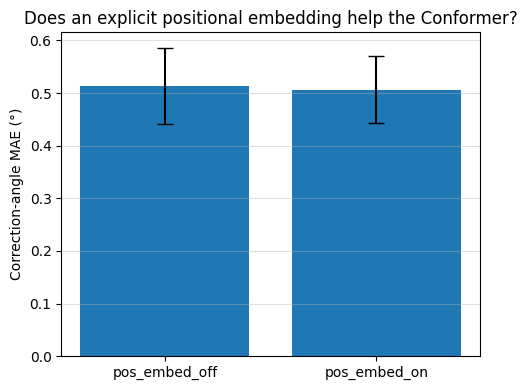

In [12]:
# Positional-embedding on/off on the DUAL backbone (their actual model), same folds.
#   Heavy: 2 arms x N_SPLITS folds x ARCH_EPOCHS.
import numpy as np
ARCH_RESULTS_2 = {}
for arm, pe in [("pos_embed_off", False), ("pos_embed_on", True)]:
    _m = build_arch(branch="dual", use_pos_embed=pe); _p = count_active_params(_m, "dual", pe); del _m
    print(f"\n########## ARM: {arm}  (active params {_p/1e6:.2f} M) ##########")
    folds = run_kfold_arch(lambda v=pe: build_arch(branch="dual", use_pos_embed=v), label=arm)
    ARCH_RESULTS_2[arm] = {"folds": folds, "params": _p}

summarize_arch(ARCH_RESULTS_2,
               "Tier-2 ablation 2 - positional embedding off vs on (dual backbone, 5-fold CV)",
               baseline="pos_embed_off")

arms  = list(ARCH_RESULTS_2)
means = [np.mean([f["stats"]["mae"] for f in ARCH_RESULTS_2[a]["folds"] if f["stats"]]) for a in arms]
stds  = [np.std([f["stats"]["mae"]  for f in ARCH_RESULTS_2[a]["folds"] if f["stats"]]) for a in arms]
plt.figure(figsize=(5, 4))
plt.bar(arms, means, yerr=stds, capsize=6)
plt.ylabel("Correction-angle MAE (\u00b0)")
plt.title("Does an explicit positional embedding help the Conformer?")
plt.grid(axis="y", alpha=0.4); plt.tight_layout(); plt.show()
